In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from helper_code.options_reader import read_options_data
from analysis_utils import (
    load_span, combine_iv_rv, plot_vrp, summarise_vrp_ticker, plot_vrp_pnl
)

start_month = "2025-01"
end_month   = "2025-01"
BASE_DIR = Path.cwd()
file_path = BASE_DIR / "vrp_results"

all_ivs = load_span(file_path, start_month, end_month, prefix="ivs")
all_signals = load_span(file_path, start_month, end_month, prefix="signals")


print("Number of tickers: ", len(all_ivs["ticker"].unique()))
all_ivs

Number of tickers:  30


,ticker,trade_date,expiry,yte,stkPx,atm_iv,implied_var30,iv30
0,SPY,2025-01-02,2025-01-31,0.07945,584.179993,0.149685,0.031280,0.176862
1,QQQ,2025-01-02,2025-01-31,0.07945,509.630005,0.193869,0.048687,0.220651
2,SPX,2025-01-02,2025-01-31,0.07945,5884.479980,0.135349,0.033102,0.181939
3,TSLA,2025-01-02,2025-01-31,0.07945,378.329987,0.682324,0.545151,0.738343
4,AAPL,2025-01-02,2025-01-31,0.07945,243.550003,0.250621,0.086982,0.294927
...,...,...,...,...,...,...,...,...
595,GME,2025-01-31,2025-02-28,0.07671,27.160000,0.583676,0.503848,0.709823
596,BA,2025-01-31,2025-02-28,0.07671,176.440002,0.305194,0.099404,0.315284
597,NFLX,2025-01-31,2025-02-28,0.07671,975.739990,0.247490,0.068463,0.261653
598,DIS,2025-01-31,2025-02-28,0.07671,113.050003,0.378083,0.147554,0.384127


In [12]:
all_signals.head()

,ticker,trade_date,rv30_yz,rv30_cc,iv30,iv60,forward_iv_30_60,forward_factor_30_60,ts45,iv30_rv30,avg_volume,expected_move_pct
0,SPY,2025-01-02,0.127706,0.143850,0.154974,0.147204,0.139001,0.114913,-0.002319,1.213520,5.188324e+07,3.62
1,QQQ,2025-01-02,0.165695,0.198040,0.197088,0.189090,0.180737,0.090467,-0.001328,1.189467,3.060233e+07,4.62
2,SPX,2025-01-02,0.120068,0.143107,0.136348,0.139533,0.142647,-0.044155,-0.000985,1.135590,0.000000e+00,3.29
3,TSLA,2025-01-02,0.646233,0.696710,0.679946,0.621130,0.556128,0.222643,-0.002381,1.052169,9.216003e+07,15.40
4,AAPL,2025-01-02,0.172423,0.189212,0.247873,0.225141,0.199839,0.240363,-0.000785,1.437590,4.714260e+07,5.69


In [10]:
vrp_df = combine_iv_rv(all_signals, all_ivs)
vrp_df.to_excel(BASE_DIR / "vrp_results" / "iv_rv_comparison.xlsx", index=False)

# print all the tickers in the dataframe
print(vrp_df["ticker"].unique())

vrp_df

['AAL' 'AAPL' 'AMC' 'AMD' 'AMZN' 'BA' 'BABA' 'BAC' 'DIS' 'EEM' 'EWZ' 'GLD'
 'GME' 'GOOGL' 'HYG' 'INTC' 'IWM' 'MSFT' 'NFLX' 'NIO' 'NVDA' 'QQQ' 'SLV'
 'SPX' 'SPY' 'TLT' 'TQQQ' 'TSLA' 'VIX' 'XLF']


,ticker,trade_date,rv30_yz,rv30_cc,rvar30,iv30,implied_var30,forward_rvar30,forward_rv30,vrp
0,AAL,2025-01-02,0.504465,0.593472,0.254485,0.524002,0.274578,NaN,NaN,NaN
1,AAL,2025-01-03,0.511714,0.591281,0.261851,0.533746,0.284885,NaN,NaN,NaN
2,AAL,2025-01-06,0.520141,0.593153,0.270546,0.506221,0.256260,NaN,NaN,NaN
3,AAL,2025-01-07,0.431232,0.254806,0.185961,0.499435,0.249436,NaN,NaN,NaN
4,AAL,2025-01-08,0.418907,0.255630,0.175483,0.517869,0.268188,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
595,XLF,2025-01-27,0.153357,0.158771,0.023518,0.163892,0.026861,NaN,NaN,NaN
596,XLF,2025-01-28,0.154835,0.156113,0.023974,0.164899,0.027192,NaN,NaN,NaN
597,XLF,2025-01-29,0.154580,0.156453,0.023895,0.162610,0.026442,NaN,NaN,NaN
598,XLF,2025-01-30,0.153306,0.154441,0.023503,0.169223,0.028636,NaN,NaN,NaN


In [5]:
vrp_grouped = vrp_df.groupby("ticker")
rows = []
for ticker, group in vrp_grouped:

    # print(f"Processing ticker: {ticker}")
    vrp_df_ticker = group.sort_values("trade_date").reset_index(drop=True)
    vrp_dict = summarise_vrp_ticker(vrp_df_ticker, ticker)
    rows.append(vrp_dict)

summary_df = pd.DataFrame(rows)
summary_df.to_excel(BASE_DIR / "tabs_and_figs" / "vrp_summary.xlsx", index=False)

summary_df

,ticker,mean_implied_var,mean_rvar,mean_vrp,var_vrp,skew_vrp,t_naive,p_naive_one_sided,t_hac,p_hac_one_sided,t_nonoverlap,p_nonoverlap_one_sided
0,AAL,0.447,0.362,0.0849,0.3971,1.4224,5.61,0.0000,1.79,0.0363,0.77,0.2226
1,AAPL,0.107,0.098,0.0091,0.0135,-4.4002,3.26,0.0006,0.90,0.1842,0.87,0.1929
2,AMC,1.932,1.423,0.5086,5.5246,0.8330,8.86,0.0000,2.87,0.0021,1.30,0.0994
3,AMD,0.298,0.280,0.0185,0.0542,-2.5811,3.32,0.0005,0.94,0.1729,0.75,0.2271
4,AMZN,0.136,0.126,0.0095,0.0089,-2.4732,4.18,0.0000,1.15,0.1257,1.02,0.1555
5,BA,0.210,0.221,-0.0117,0.2218,-7.5629,-1.03,0.8490,-0.29,0.6135,-0.36,0.6395
6,BABA,0.221,0.219,0.0022,0.0219,-3.1566,0.63,0.2633,0.19,0.4265,-0.02,0.5074
7,BAC,0.118,0.117,0.0010,0.0365,-6.8364,0.22,0.4149,0.06,0.4759,-0.05,0.5186
8,DIS,0.113,0.104,0.0092,0.0152,-6.6746,3.04,0.0012,0.85,0.1963,0.22,0.4121
9,EEM,0.050,0.046,0.0044,0.0073,-6.7539,2.15,0.0158,0.61,0.2700,0.38,0.3541


## Box Plot

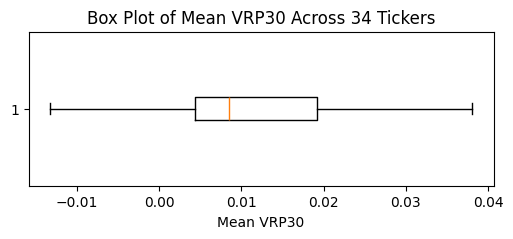

In [6]:
plt.figure(figsize=(6, 2))
plt.boxplot(summary_df["mean_vrp"], vert=False, showfliers=False)
# plt.xlim(-0.1, 0.2)  # choose appropriate bounds
plt.title(f"Box Plot of Mean VRP30 Across {len(summary_df)} Tickers")
plt.xlabel("Mean VRP30")

# save the figure
plt.savefig(BASE_DIR / "tabs_and_figs" / "boxplot_mean_vrp30.png", bbox_inches="tight")

plt.show()

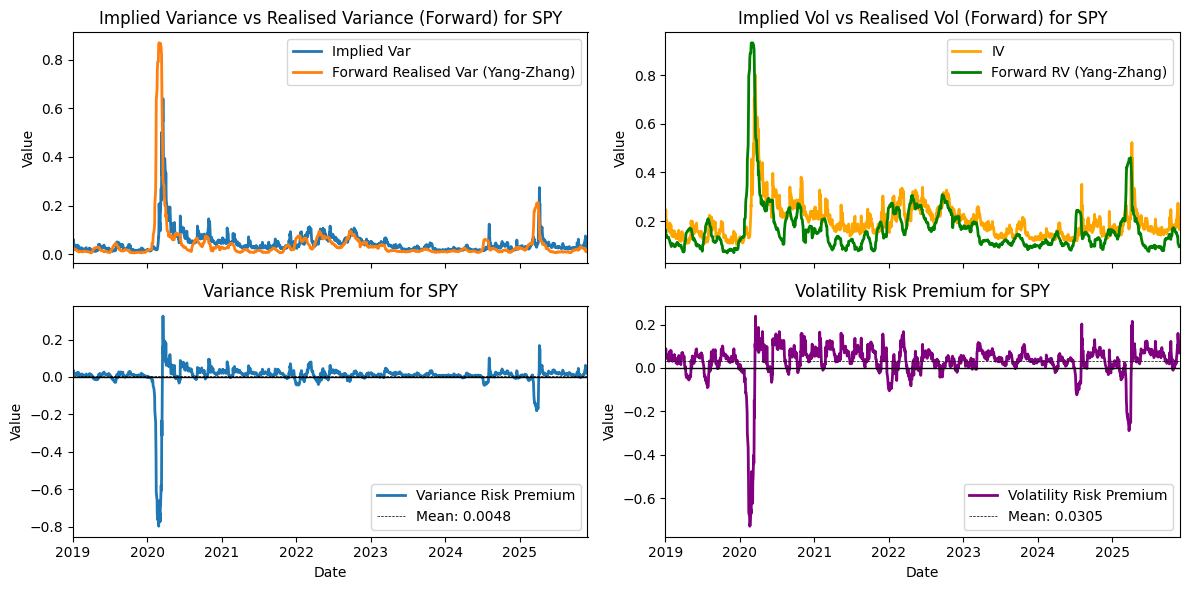

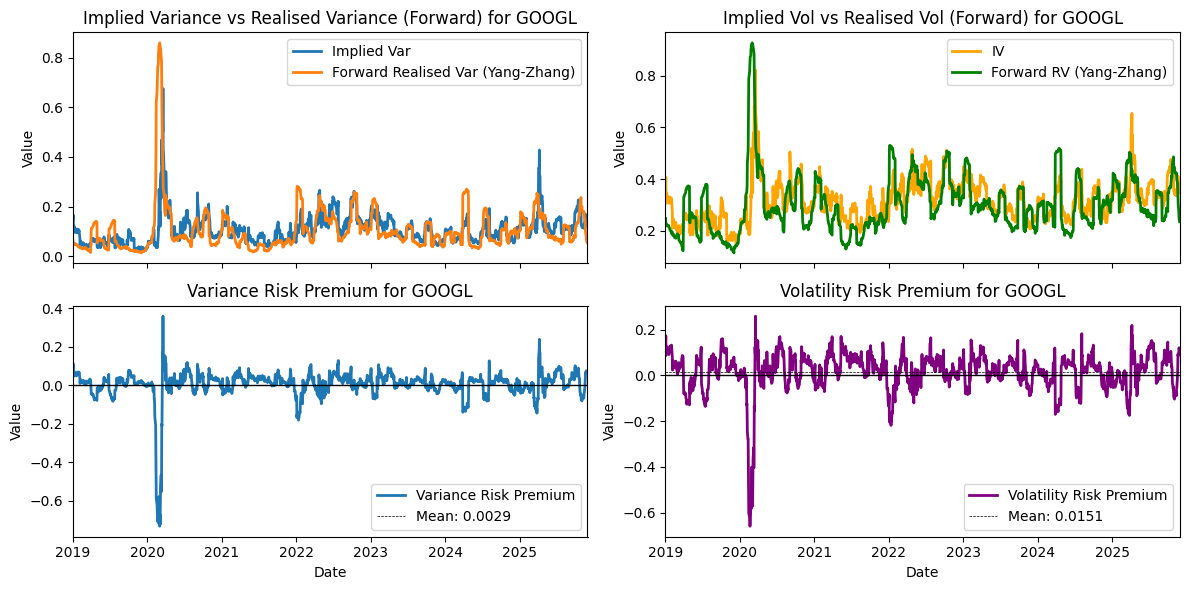

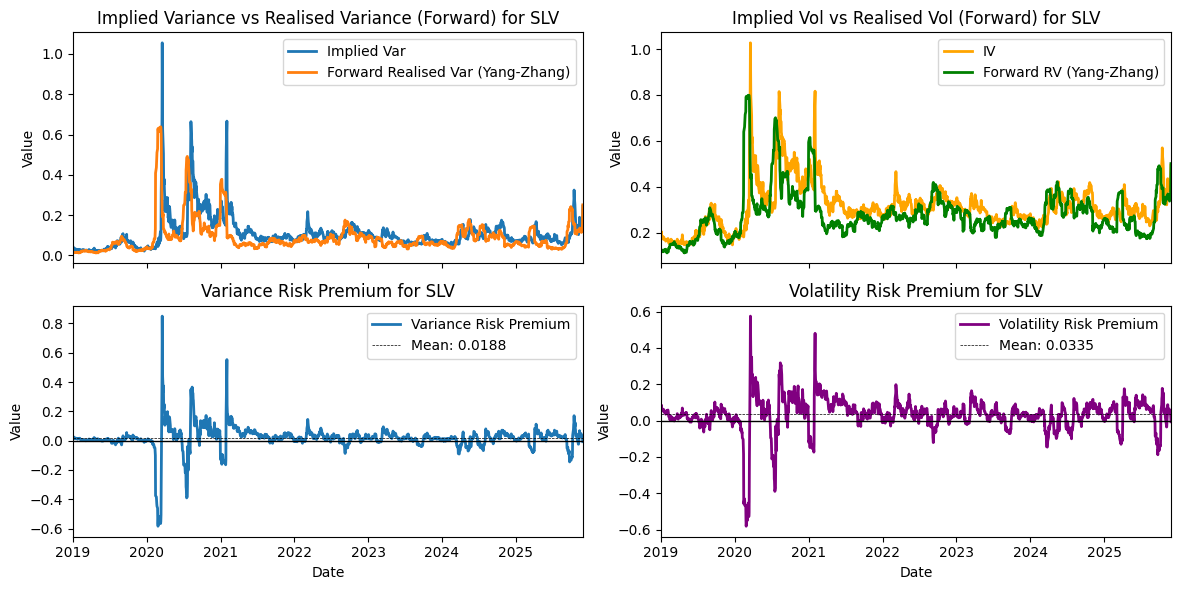

In [ ]:
ticker_list = ["SPY", "GOOGL", "SLV"]

for ticker in ticker_list:
    vrp_df_ticker = vrp_df[vrp_df["ticker"] == ticker].sort_values("trade_date").reset_index(drop=True)
    vrp_df_ticker = vrp_df_ticker.dropna()
    plot_vrp(vrp_df_ticker, ticker=ticker, path = BASE_DIR / "tabs_and_figs")

## Investigation and Debug

In [8]:
vrp_df_spx = vrp_df[vrp_df["ticker"] == "VIX"].sort_values("trade_date").reset_index(drop=True)

# print 2021-01-01 to 2021-01-31
vrp_df_spx_jan2021 = vrp_df_spx[(vrp_df_spx["trade_date"] >= "2020-12-01") & (vrp_df_spx["trade_date"] <= "2021-01-31")].reset_index(drop=True)
vrp_df_spx_jan2021

,ticker,trade_date,rv30_yz,rv30_cc,rvar30,iv30,implied_var30,forward_rvar30,forward_rv30,vrp
0,VIX,2020-12-01,1.209186,0.905758,1.462131,1.038536,1.078557,1.621253,1.273284,-0.542696
1,VIX,2020-12-02,1.207988,0.920783,1.459236,1.022126,1.044742,1.654480,1.286266,-0.609738
2,VIX,2020-12-03,1.207065,0.925065,1.457006,1.077727,1.161495,1.926069,1.387829,-0.764574
3,VIX,2020-12-04,1.109973,0.720213,1.232040,1.130793,1.278693,2.006023,1.416341,-0.727329
4,VIX,2020-12-07,1.069274,0.706651,1.143346,1.021523,1.043508,2.165750,1.471649,-1.122242
5,VIX,2020-12-08,1.031207,0.627881,1.063388,1.037375,1.076146,2.189373,1.479653,-1.113227
6,VIX,2020-12-09,0.964411,0.674882,0.930088,1.059432,1.122396,2.158215,1.469086,-1.035819
7,VIX,2020-12-10,0.974622,0.668056,0.949888,1.034198,1.069565,2.229499,1.493151,-1.159935
8,VIX,2020-12-11,0.969401,0.653729,0.939739,1.276918,1.630519,2.206528,1.485439,-0.576009
9,VIX,2020-12-14,0.949871,0.627682,0.902254,1.221511,1.492089,2.181046,1.476837,-0.688958
